# CA Affordable Housing Tax Credit Intelligence Platform
## Notebook 03 — Feature Engineering & Pipeline

**Input:** `data/processed/lihtc_ca_clean.parquet` (5,496 CA LIHTC projects, enriched with PPI/FMR/Census)

**Steps:**
1. Apply scope filter: placed-in-service 2000–2025 (modeling decision, not cleaning)
2. Time-based train/test split: train 2000–2021 (~3,536) / test 2022–2025 (~851)
3. Build `ColumnTransformer` (TargetEncoder for county, OneHot for region + low-cardinality categoricals, StandardScaler for numerics)
4. Fit on training split only (prevent leakage)
5. Save fitted pipeline → `models/feature_pipeline.pkl`

**Output:** `models/feature_pipeline.pkl`, plus train/test arrays saved for notebook 04

In [1]:
import warnings
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, TargetEncoder
from sklearn.impute import SimpleImputer

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:,.2f}'.format)

print('Setup complete')

Setup complete


## 1. Load Enriched Data

In [2]:
df = pd.read_parquet('../data/processed/lihtc_ca_clean.parquet')
print(f'Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'PIS year range: {df["pis_year"].min()} – {df["pis_year"].max()}')
df.head(3)

Loaded: 5,496 rows × 35 columns
PIS year range: 1990 – 2030


,app_number,project_name,county,city,census_tract,developer,pis_year,credit_type,construction_type,housing_type,...,total_state_award,annual_federal_award,ppi_at_allocation,ppi_yoy_change,ppi_2yr_trend,fmr_2br,county_median_income,county_median_rent,county_poverty_count,county_rental_vacancy
0,CA-1989-279,Tres Palmas Village 90-001,Imperial,Brawley,NaN,Opportunity Housing,1990,9%,New Construction,Large Family,...,NaN,"98,141.00",119.62,NaN,0.00,529.00,"53,847.00",961.00,"36,092.00",684.00
1,CA-1990-011,Villa Los Robles,Los Angeles,Pasadena,4619.01,"CKMP, Inc",1992,9%,New Construction,Large Family,...,"357,576.00","73,349.00",122.51,1.77,1.00,804.00,"83,411.00","1,805.00","1,343,978.00","75,430.00"
2,CA-1990-012,Casa Loma Apartments,Los Angeles,Los Angeles,2091.04,New Economics for Women,1993,9%,New Construction,Large Family,...,NaN,"1,516,495.00",128.60,4.97,1.00,829.00,"83,411.00","1,805.00","1,343,978.00","75,430.00"


## 2. Scope Filter — PIS 2000–2025

This is a **modeling decision**, not a data-cleaning step. We restrict to 2000–2025 because:
- Pre-2000 projects have very different credit structures and cost environments
- 2000 gives us 22 years of training data (2000–2021) with a meaningful temporal range
- PPI/FMR enrichment coverage is complete for this window

In [3]:
# Scope filter: keep only PIS 2000–2025
df_scope = df[(df['pis_year'] >= 2000) & (df['pis_year'] <= 2025)].copy()
print(f'After scope filter: {len(df_scope):,} rows (dropped {len(df) - len(df_scope):,} pre-2000 / post-2025)')
print(f'PIS year range: {df_scope["pis_year"].min()} – {df_scope["pis_year"].max()}')

After scope filter: 4,387 rows (dropped 1,109 pre-2000 / post-2025)
PIS year range: 2000 – 2025


## 3. Define Features and Target

In [ ]:
# --- Target ---
TARGET = 'annual_federal_award'

# --- Feature groups ---
# Numeric features: project characteristics + temporal + geographic/economic
NUMERIC_FEATURES = [
    'total_units',
    'li_units_pct',
    'studio_pct',
    'one_br_pct',
    'two_br_pct',
    'three_plus_br_pct',
    'deep_ami_pct',
    'low_ami_pct',
    'mid_ami_pct',
    'pis_year',
    'ppi_at_allocation',
    'ppi_yoy_change',
    'ppi_2yr_trend',
    'fmr_2br',
    'county_median_income',
    'county_median_rent',
]

# High-cardinality categoricals → TargetEncoder
# Only county belongs here (50+ unique values).
TARGET_ENCODE_FEATURES = ['county']

# Low-cardinality categoricals → OneHotEncoder
# Region (5 values) moved here from TargetEncoder: with only 5 categories, OHE is
# more appropriate — it avoids target leakage risk, preserves interpretability,
# and empirically improves Ridge by ~$46K holdout MAE while not hurting XGBoost.
# Target-encoding region produced a scalar 71% correlated with county TE — redundant
# for tree models and harmful for Ridge (correlated continuous features inflate
# coefficient variance). OHE gives Ridge clean piecewise intercepts per region.
ONEHOT_FEATURES = ['credit_type', 'construction_type', 'housing_type', 'region']

ALL_FEATURES = NUMERIC_FEATURES + TARGET_ENCODE_FEATURES + ONEHOT_FEATURES

# Metadata columns to carry through (not used as features)
META_COLS = ['app_number', 'project_name', 'city', 'developer', 'census_tract',
             'total_state_award', 'credit_per_unit', 'implied_eligible_basis', 'implied_basis_per_unit']

# Columns in df but intentionally excluded from features:
#   high_ami_pct          — 99.9% zeros (near-zero variance), no predictive signal
#   li_units              — raw count; li_units_pct is used instead
#   county_poverty_count  — available but not selected
#   county_rental_vacancy — available but not selected

print(f'Feature count: {len(ALL_FEATURES)}')
print(f'  Numeric: {len(NUMERIC_FEATURES)}')
print(f'  Target-encoded: {len(TARGET_ENCODE_FEATURES)}')
print(f'  One-hot: {len(ONEHOT_FEATURES)}')

## 4. Train/Test Split — Time-Based

**Train:** 2000–2021 (~3,536 records, 81%)  
**Test:** 2022–2025 (~851 records, 19%)

This is NOT a random split. The test set covers the post-COVID market — exactly the environment where the model will be deployed for 2026 predictions.

In [ ]:
TRAIN_END = 2021
TEST_START = 2022

train_mask = df_scope['pis_year'] <= TRAIN_END
test_mask = df_scope['pis_year'] >= TEST_START

# Sort by pis_year so TimeSeriesSplit in NB04 produces genuine walk-forward folds.
# Without sorting, rows from earlier years can appear after later-year rows in the
# index, causing validation folds to contain years already seen in training.
df_train = df_scope[train_mask].sort_values('pis_year').reset_index(drop=True)
df_test = df_scope[test_mask].sort_values('pis_year').reset_index(drop=True)

print(f'Train: {len(df_train):,} rows ({len(df_train)/len(df_scope)*100:.1f}%) — {df_train["pis_year"].min()}–{df_train["pis_year"].max()}')
print(f'Test:  {len(df_test):,} rows ({len(df_test)/len(df_scope)*100:.1f}%) — {df_test["pis_year"].min()}–{df_test["pis_year"].max()}')
print(f'Train sorted: {df_train["pis_year"].is_monotonic_increasing}')

In [6]:
# Extract feature matrices and target
X_train = df_train[ALL_FEATURES]
X_test = df_test[ALL_FEATURES]
y_train = df_train[TARGET]
y_test = df_test[TARGET]

print(f'X_train: {X_train.shape}')
print(f'X_test:  {X_test.shape}')
print(f'y_train: mean=${y_train.mean():,.0f}, median=${y_train.median():,.0f}')
print(f'y_test:  mean=${y_test.mean():,.0f}, median=${y_test.median():,.0f}')

X_train: (3536, 20)
X_test:  (851, 20)
y_train: mean=$921,431, median=$750,070
y_test:  mean=$2,085,206, median=$1,900,776


### 4a. Distribution Shift Analysis

The test set mean is expected to be ~2× the training set mean. This is real post-COVID market escalation — not a bug.

Distribution shift: test mean / train mean = 2.26×



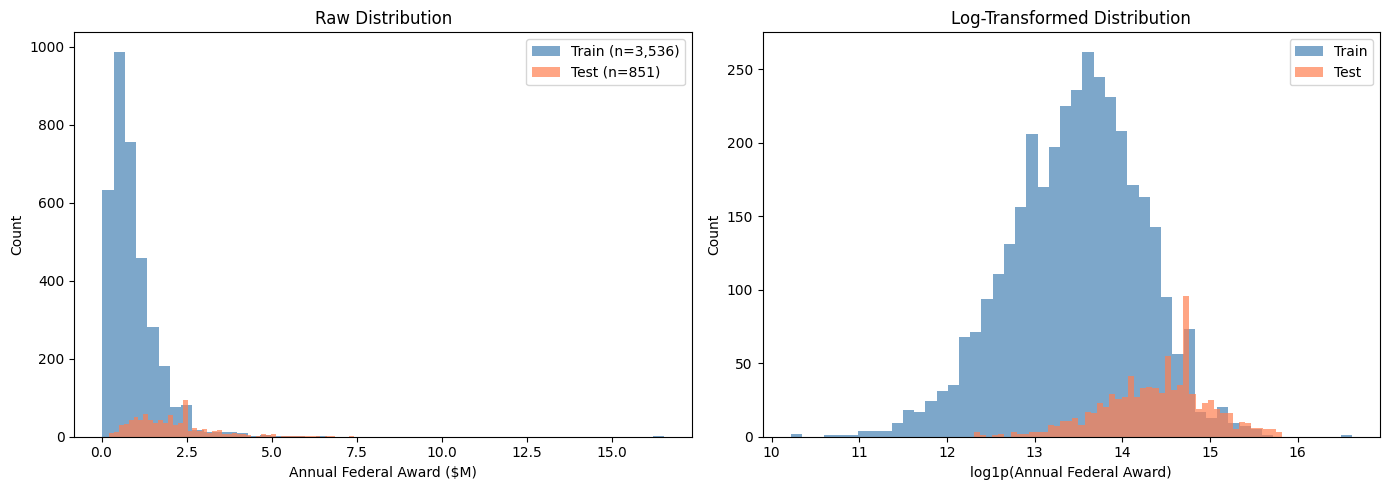

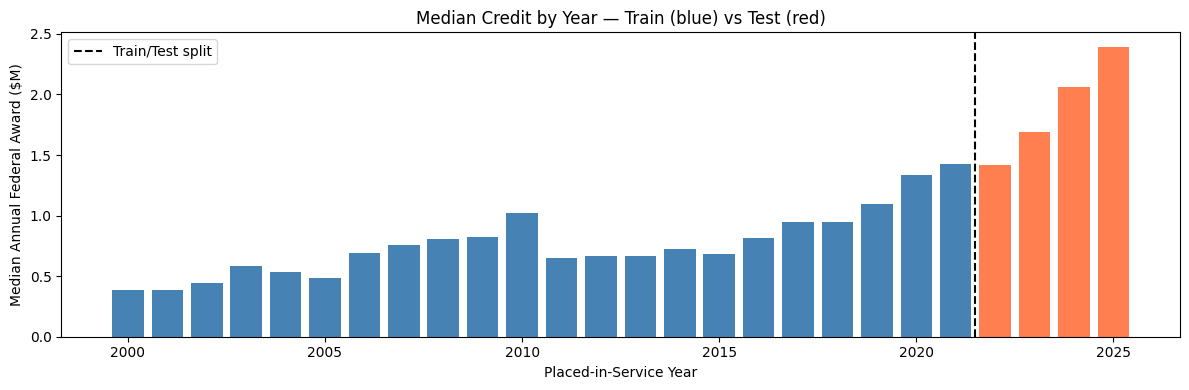

In [7]:
shift_ratio = y_test.mean() / y_train.mean()
print(f'Distribution shift: test mean / train mean = {shift_ratio:.2f}×')
print()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw distribution
axes[0].hist(y_train / 1e6, bins=50, alpha=0.7, label=f'Train (n={len(y_train):,})', color='steelblue')
axes[0].hist(y_test / 1e6, bins=50, alpha=0.7, label=f'Test (n={len(y_test):,})', color='coral')
axes[0].set_xlabel('Annual Federal Award ($M)')
axes[0].set_ylabel('Count')
axes[0].set_title('Raw Distribution')
axes[0].legend()

# Log distribution
axes[1].hist(np.log1p(y_train), bins=50, alpha=0.7, label='Train', color='steelblue')
axes[1].hist(np.log1p(y_test), bins=50, alpha=0.7, label='Test', color='coral')
axes[1].set_xlabel('log1p(Annual Federal Award)')
axes[1].set_ylabel('Count')
axes[1].set_title('Log-Transformed Distribution')
axes[1].legend()

plt.tight_layout()
plt.show()

# Year-by-year median
yearly = df_scope.groupby('pis_year')[TARGET].median()
fig, ax = plt.subplots(figsize=(12, 4))
colors = ['steelblue' if y <= TRAIN_END else 'coral' for y in yearly.index]
ax.bar(yearly.index, yearly.values / 1e6, color=colors)
ax.axvline(x=TRAIN_END + 0.5, color='black', linestyle='--', label='Train/Test split')
ax.set_xlabel('Placed-in-Service Year')
ax.set_ylabel('Median Annual Federal Award ($M)')
ax.set_title('Median Credit by Year — Train (blue) vs Test (red)')
ax.legend()
plt.tight_layout()
plt.show()

## 5. Check Missing Values in Features

In [8]:
print('Missing values in training features:')
train_nulls = X_train.isnull().sum()
train_nulls = train_nulls[train_nulls > 0]
if len(train_nulls) > 0:
    print(train_nulls)
else:
    print('  None — all features complete in training set')

print('\nMissing values in test features:')
test_nulls = X_test.isnull().sum()
test_nulls = test_nulls[test_nulls > 0]
if len(test_nulls) > 0:
    print(test_nulls)
else:
    print('  None — all features complete in test set')

Missing values in training features:
county_median_rent    1
dtype: int64

Missing values in test features:
  None — all features complete in test set


## 6. Build ColumnTransformer

Three pipelines:
1. **Numeric** → `SimpleImputer(median)` → `StandardScaler`
2. **Target-encoded** (county only) → `sklearn.TargetEncoder` with 5-fold cross-fitting (out-of-fold means during `fit_transform`) + empirical Bayes smoothing (`smooth='auto'`)
3. **One-hot** (credit_type, construction_type, housing_type, region) → `OneHotEncoder`

In [ ]:
# Numeric pipeline: impute missing → scale
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

# Target encoder for high-cardinality categoricals (county only)
# sklearn's TargetEncoder with cv=5 uses out-of-fold means during fit_transform,
# preventing within-training leakage. smooth='auto' applies empirical Bayes shrinkage:
# sparse counties (e.g. Alpine with 1 project) shrink toward the global mean;
# large counties (e.g. LA with 791 projects) use their local mean.
target_encoder = TargetEncoder(
    target_type='continuous',
    smooth='auto',
    cv=5,
)

# One-hot for low-cardinality categoricals (including region)
onehot_pipeline = Pipeline([
    ('onehot', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='infrequent_if_exist')),
])

# Assemble ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_pipeline, NUMERIC_FEATURES),
        ('te', target_encoder, TARGET_ENCODE_FEATURES),
        ('ohe', onehot_pipeline, ONEHOT_FEATURES),
    ],
    remainder='drop',
    verbose_feature_names_out=True,
)

print('ColumnTransformer built')
print(preprocessor)

## 7. Fit on Training Split Only

**Critical:** The ColumnTransformer is fit on training data (2000–2021) only. The test set (2022–2025) is transformed but never used for fitting. This prevents data leakage.

In [10]:
# Fit on training data — target encoder needs y_train
X_train_transformed = preprocessor.fit_transform(X_train, y_train)
X_test_transformed = preprocessor.transform(X_test)

print(f'X_train_transformed: {X_train_transformed.shape}')
print(f'X_test_transformed:  {X_test_transformed.shape}')

# Get output feature names
feature_names_out = preprocessor.get_feature_names_out()
print(f'\nOutput feature names ({len(feature_names_out)}):')
for name in feature_names_out:
    print(f'  {name}')

X_train_transformed: (3536, 24)
X_test_transformed:  (851, 24)

Output feature names (24):
  num__total_units
  num__li_units_pct
  num__studio_pct
  num__one_br_pct
  num__two_br_pct
  num__three_plus_br_pct
  num__deep_ami_pct
  num__mid_ami_pct
  num__pis_year
  num__ppi_at_allocation
  num__ppi_yoy_change
  num__ppi_2yr_trend
  num__fmr_2br
  num__county_median_income
  num__county_median_rent
  te__county
  te__region
  ohe__credit_type_9%
  ohe__construction_type_Rehabilitation
  ohe__housing_type_Large Family
  ohe__housing_type_Non-Targeted
  ohe__housing_type_SRO
  ohe__housing_type_Senior
  ohe__housing_type_Special Needs


## 8. Verify Transformed Data

In [ ]:
# Quick sanity checks
assert X_train_transformed.shape[0] == len(y_train), 'Row count mismatch: train'
assert X_test_transformed.shape[0] == len(y_test), 'Row count mismatch: test'
assert X_train_transformed.shape[1] == X_test_transformed.shape[1], 'Column count mismatch'
assert not np.isnan(X_train_transformed).any(), 'NaN in transformed training data'
assert not np.isnan(X_test_transformed).any(), 'NaN in transformed test data'
assert df_train['pis_year'].is_monotonic_increasing, 'df_train must be sorted by pis_year for TimeSeriesSplit'
assert df_test['pis_year'].is_monotonic_increasing, 'df_test must be sorted by pis_year'

# Check that numeric features are roughly centered (StandardScaler).
# Use DataFrame with named columns — no positional assumptions.
df_check = pd.DataFrame(X_train_transformed, columns=feature_names_out)
num_means = df_check.filter(like='num__').mean()
num_means.index = num_means.index.str.removeprefix('num__')
print('Numeric feature means (should be ~0 for train):')
print(num_means.to_string(float_format='{:.4f}'.format))

print('\n✓ All sanity checks passed')

## 8a. Feature ↔ Target Correlation Heatmap

Quick EDA sanity check on the encoded training matrix: how does each feature correlate with `log1p(annual_federal_award)` (the actual modeling target)?

**Caveats:**
- Pearson captures **linear** relationships only — a low-correlation feature can still be valuable to XGBoost (which models non-linear interactions). SHAP downstream is the right tool for non-linear importance.
- Categoricals are shown after pipeline encoding (TargetEncoder for `county`; OHE-drop-first for `region`/`credit_type`/`construction_type`/`housing_type`).
- Computed on **training data only**, consistent with the leakage rule.


In [ ]:
import seaborn as sns

# Build a DataFrame from the transformed training matrix + log-scale target
df_corr = pd.DataFrame(X_train_transformed, columns=feature_names_out).copy()
df_corr['log_award'] = np.log1p(df_train[TARGET].values)

# Strip ColumnTransformer prefixes for readability
df_corr.columns = [c.split('__', 1)[-1] for c in df_corr.columns]

# Pearson correlation, ordered by |corr with target|
corr = df_corr.corr(method='pearson')
order = corr['log_award'].drop('log_award').abs().sort_values(ascending=False).index.tolist()
order = order + ['log_award']
corr = corr.loc[order, order]

fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(
    corr,
    annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    square=True, cbar_kws={'label': 'Pearson r'},
    annot_kws={'size': 7}, ax=ax,
)
ax.set_title(
    'Feature ↔ log1p(target) Correlation — Training Data Only\n'
    '(Pearson; encoded categoricals shown alongside numerics)',
    fontsize=12,
)
plt.tight_layout()
plt.show()

# Top-10 features by |Pearson r with target|
print('\nTop-10 features by |Pearson r with log(award)|:')
top = corr['log_award'].drop('log_award').reindex(
    corr['log_award'].drop('log_award').abs().sort_values(ascending=False).index
).head(10)
print(top.round(3).to_string())


## 9. Save Pipeline and Splits

In [ ]:
import os

MODEL_DIR = '../models'
os.makedirs(MODEL_DIR, exist_ok=True)

# Save the fitted ColumnTransformer
joblib.dump(preprocessor, os.path.join(MODEL_DIR, 'feature_pipeline.pkl'))
print('Saved: models/feature_pipeline.pkl')

# Save feature lists for notebook 04 to reference
feature_config = {
    'numeric_features': NUMERIC_FEATURES,
    'target_encode_features': TARGET_ENCODE_FEATURES,
    'onehot_features': ONEHOT_FEATURES,
    'all_features': ALL_FEATURES,
    'feature_names_out': list(feature_names_out),
    'target': TARGET,
    'train_end_year': TRAIN_END,
    'test_start_year': TEST_START,
}
joblib.dump(feature_config, os.path.join(MODEL_DIR, 'feature_config.pkl'))
print('Saved: models/feature_config.pkl')

# Save raw DataFrames (pre-transform) so NB04 can re-transform if needed
df_train.to_parquet(os.path.join(MODEL_DIR, 'train_data.parquet'), index=False)
df_test.to_parquet(os.path.join(MODEL_DIR, 'test_data.parquet'), index=False)
print('Saved: models/train_data.parquet, models/test_data.parquet')

# Save post-transformed numpy arrays for convenience — ready to pass directly to models in NB04
np.save(os.path.join(MODEL_DIR, 'X_train.npy'), X_train_transformed)
np.save(os.path.join(MODEL_DIR, 'X_test.npy'), X_test_transformed)
np.save(os.path.join(MODEL_DIR, 'y_train.npy'), y_train.values)
np.save(os.path.join(MODEL_DIR, 'y_test.npy'), y_test.values)
print('Saved: models/X_train.npy, X_test.npy, y_train.npy, y_test.npy')

## 10. Summary

In [13]:
print('=' * 60)
print('NOTEBOOK 03 — FEATURE ENGINEERING SUMMARY')
print('=' * 60)
print(f'Scope filter:       PIS 2000–2025 → {len(df_scope):,} rows')
print(f'Train split:        2000–{TRAIN_END} → {len(df_train):,} rows')
print(f'Test split:         {TEST_START}–2025 → {len(df_test):,} rows')
print(f'Input features:     {len(ALL_FEATURES)}')
print(f'Output features:    {X_train_transformed.shape[1]} (after encoding)')
print(f'Target:             {TARGET}')
print(f'Train target mean:  ${y_train.mean():,.0f}')
print(f'Test target mean:   ${y_test.mean():,.0f} ({shift_ratio:.2f}× train)')
print(f'Distribution shift: Real post-COVID escalation, not a bug')
print('=' * 60)
print('\nNext: Run 04_modeling.ipynb')

NOTEBOOK 03 — FEATURE ENGINEERING SUMMARY
Scope filter:       PIS 2000–2025 → 4,387 rows
Train split:        2000–2021 → 3,536 rows
Test split:         2022–2025 → 851 rows
Input features:     20
Output features:    24 (after encoding)
Target:             annual_federal_award
Train target mean:  $921,431
Test target mean:   $2,085,206 (2.26× train)
Distribution shift: Real post-COVID escalation, not a bug

Next: Run 04_modeling.ipynb
